In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib

In [94]:
df = pd.read_csv("/content/drive/MyDrive/Datapattern/epa_air_quality_annual_summary.csv")
df.head()

/tmp/ipykernel_6408/4263338323.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Datapattern/epa_air_quality_annual_summary.csv")


,state_code,county_code,site_num,parameter_code,poc,latitude,longitude,datum,parameter_name,sample_duration,...,seventy_five_percentile,fifty_percentile,ten_percentile,local_site_name,address,state_name,county_name,city_name,cbsa_name,date_of_last_change
0,20,57,1,82134,1,37.771964,-100.018190,WGS84,Molybdenum PM10 STP,24 HOUR,...,0.00000,0.0,0.0,DODGE CITY,PUMP STATION 2100 1ST AVE,Kansas,Ford,Dodge City,Dodge City KS,2012-08-11
1,18,163,12,42401,1,38.021727,-87.569458,WGS84,Sulfur dioxide,3-HR BLK AVG,...,3.60000,1.3,0.0,Evansville CAAP,425 WEST MILL ROAD/ FIRE STATION #17,Indiana,Vanderburgh,Evansville,Evansville IN-KY,2013-02-16
2,40,31,9000,88152,1,34.732404,-98.713351,WGS84,Phosphorus PM2.5 LC,24 HOUR,...,0.00000,0.0,0.0,NaN,Wichita Mountains,Oklahoma,Comanche,NaN,Lawton OK,2016-02-26
3,32,3,561,42601,1,36.163959,-115.113916,WGS84,Nitric oxide (NO),1 HOUR,...,18.80000,0.9,0.0,Sunrise Acres,2501 SUNRISE AVENUE,Nevada,Clark,Las Vegas,Las Vegas-Henderson-Paradise NV,2015-03-20
4,13,127,3001,12154,1,31.185187,-81.485166,WGS84,Selenium (TSP) STP,24 HOUR,...,0.00064,0.0,0.0,NaN,BRUNSWICK COASTAL COLLEGE,Georgia,Glynn,Brunswick,Brunswick GA,2015-07-22


In [95]:
df.shape

(2038710, 55)

In [96]:
cols_to_drop = [
    'state_code', 'county_code', 'site_num', 'parameter_code',
    'address', 'local_site_name', 'city_name', 'county_name', 'state_name', 'cbsa_name',
    'datum', 'method_name', 'date_of_last_change', 'units_of_measure',
    'poc', 'pollutant_standard',
    'first_max_datetime', 'second_max_datetime', 'third_max_datetime',
    'fourth_max_datetime', 'first_no_max_datetime', 'second_no_max_datetime',
    "metric_used","certification_indicator",
    'arithmetic_mean',
    'first_max_value',
    'second_max_value',
    'third_max_value',
    'fourth_max_value',
    'ninety_nine_percentile',
    'ninety_eight_percentile',
    'ninety_percentile',
    'seventy_five_percentile',
    'fifty_percentile',
    'ten_percentile'

]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [97]:
df.isnull().sum().sort_values(ascending=False)

,0
second_max_non_overlapping_value,2020973
first_max_non_overlapping_value,2020969
secondary_exceedance_count,1706561
primary_exceedance_count,1663792
arithmetic_standard_dev,24
latitude,10
longitude,10
parameter_name,0
sample_duration,0
year,0


In [98]:
cols_to_drop = [
    "second_max_non_overlapping_value",
    "first_max_non_overlapping_value",
    "secondary_exceedance_count",
    "primary_exceedance_count"
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [99]:
df.shape

(2038710, 16)

In [100]:
df.isnull().sum().sort_values(ascending=False)

,0
arithmetic_standard_dev,24
latitude,10
longitude,10
parameter_name,0
year,0
event_type,0
observation_count,0
sample_duration,0
observation_percent,0
completeness_indicator,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2038710 entries, 0 to 2038709
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   latitude                 float64
 1   longitude                float64
 2   parameter_name           object 
 3   sample_duration          object 
 4   year                     int64  
 5   event_type               object 
 6   observation_count        int64  
 7   observation_percent      int64  
 8   completeness_indicator   object 
 9   valid_day_count          int64  
 10  required_day_count       int64  
 11  exceptional_data_count   int64  
 12  null_data_count          int64  
 13  num_obs_below_mdl        int64  
 14  arithmetic_standard_dev  float64
 15  ninety_five_percentile   float64
dtypes: float64(4), int64(8), object(4)
memory usage: 248.9+ MB


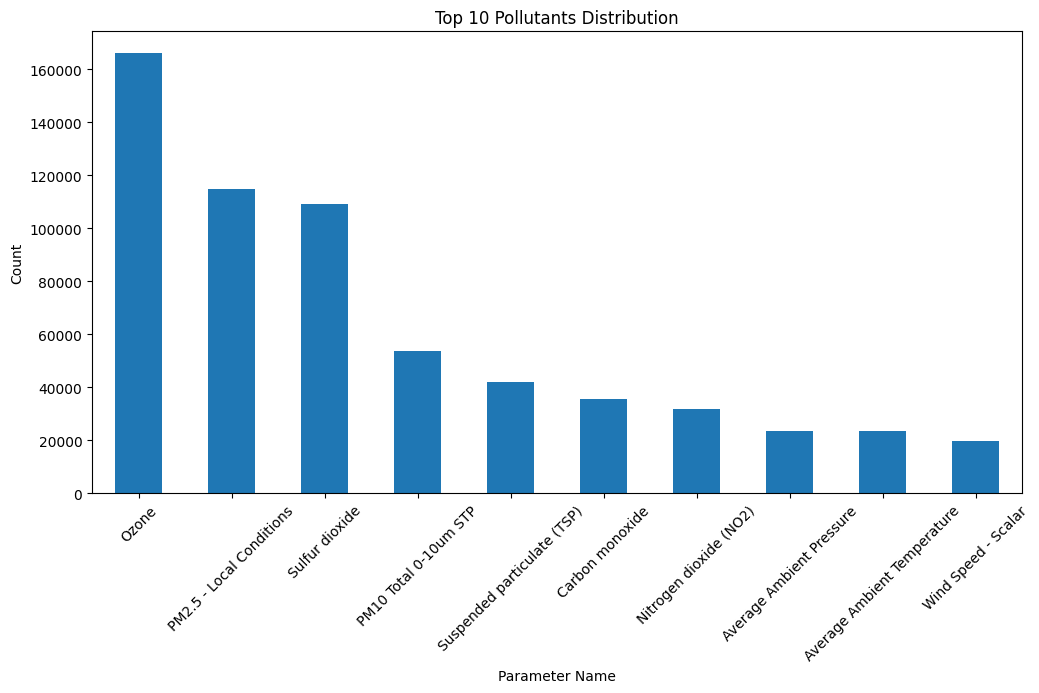

In [102]:
df['parameter_name'].value_counts().head(10).plot(kind='bar', figsize=(12,6))
plt.title("Top 10 Pollutants Distribution")
plt.xlabel("Parameter Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

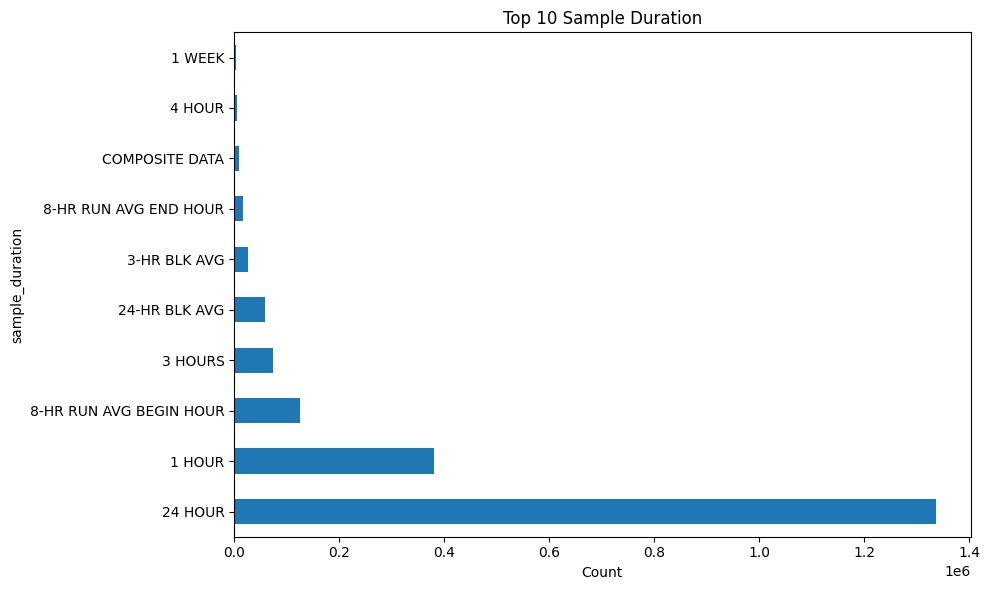

In [103]:
df['sample_duration'].value_counts().head(10).plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Sample Duration")
plt.xlabel("Count")

plt.tight_layout()
plt.show()

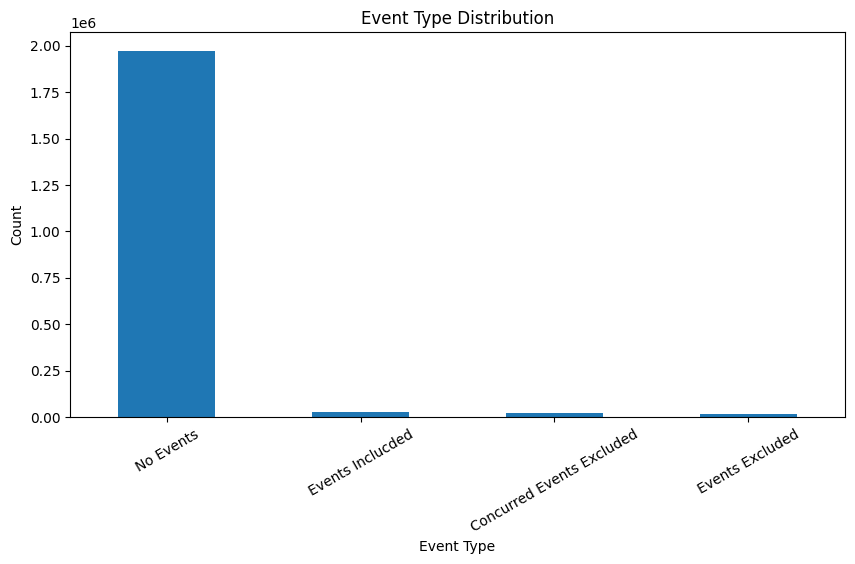

In [104]:
df['event_type'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.show()

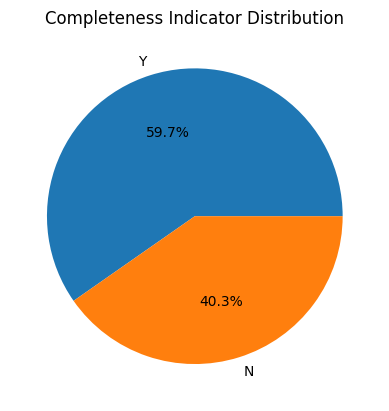

In [105]:
df['completeness_indicator'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Completeness Indicator Distribution")
plt.ylabel('')
plt.show()

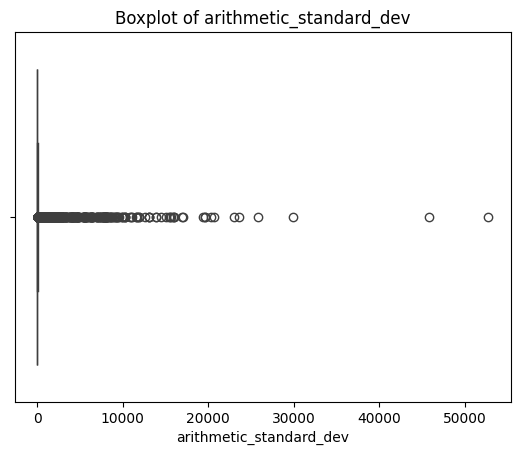

In [106]:
cols = [
    'arithmetic_standard_dev',]
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [107]:
obj_cols = df.select_dtypes(include='object').columns
for col in obj_cols:
    display(pd.DataFrame({
        'value': df[col].value_counts().index,
        'count': df[col].value_counts().values
    }).head(10))

,value,count
0,Ozone,166005
1,PM2.5 - Local Conditions,114697
2,Sulfur dioxide,109389
3,PM10 Total 0-10um STP,53687
4,Suspended particulate (TSP),42162
5,Carbon monoxide,35486
6,Nitrogen dioxide (NO2),31933
7,Average Ambient Pressure,23689
8,Average Ambient Temperature,23686
9,Wind Speed - Scalar,19767


,value,count
0,24 HOUR,1336058
1,1 HOUR,380417
2,8-HR RUN AVG BEGIN HOUR,124503
3,3 HOURS,74345
4,24-HR BLK AVG,58285
5,3-HR BLK AVG,26250
6,8-HR RUN AVG END HOUR,17741
7,COMPOSITE DATA,8524
8,4 HOUR,4477
9,1 WEEK,2801


,value,count
0,No Events,1973043
1,Events Inclucded,27367
2,Concurred Events Excluded,20766
3,Events Excluded,17534


,value,count
0,Y,1217147
1,N,821563


In [108]:
df.shape

(2038710, 16)

In [109]:
valid_pollutants = [
    'Ozone',
    'PM2.5 - Local Conditions',
    'PM10 Total 0-10um STP',
    'Sulfur dioxide',
    'Carbon monoxide',
    'Nitrogen dioxide (NO2)'
]

df['is_pollutant'] = df['parameter_name'].isin(valid_pollutants).astype(int)

In [110]:
df['is_pollutant'].value_counts()

,count
is_pollutant,
0,1527513
1,511197


In [111]:
def convert_duration(x):
    if pd.isna(x):
        return None

    if '24 HOUR' in x or '24-HR' in x:
        return 24
    elif '1 HOUR' in x:
        return 1
    elif '8-HR' in x:
        return 8
    elif '3 HOUR' in x or '3-HR' in x:
        return 3
    elif '4 HOUR' in x:
        return 4
    elif 'WEEK' in x:
        return 168
    elif 'COMPOSITE' in x:
        return None
    else:
        return None

df['sample_duration_num'] = df['sample_duration'].apply(convert_duration)

In [112]:
df['event_flag'] = (df['event_type'] != 'No Events').astype(int)


In [113]:
df['completeness_indicator'] = df['completeness_indicator'].map({'Y': 1, 'N': 0})

In [114]:
df.drop(columns=['sample_duration',"event_type","parameter_name"], inplace=True, errors='ignore')

In [115]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [116]:
df.dtypes

,0
latitude,float64
longitude,float64
year,int64
observation_count,int64
observation_percent,int64
completeness_indicator,int64
valid_day_count,int64
required_day_count,int64
exceptional_data_count,int64
null_data_count,int64


In [117]:
df.shape

(2038710, 16)

In [118]:
df['target_p95'] = (df['ninety_five_percentile'] > 35).astype(int)
df['target_p95'].value_counts()

,count
target_p95,
0,1692302
1,346408


In [119]:
df.drop(columns=['ninety_five_percentile'], inplace=True, errors='ignore')

In [120]:
df.isnull().sum().sort_values(ascending=False)

,0
sample_duration_num,13818
arithmetic_standard_dev,24
latitude,10
longitude,10
observation_percent,0
completeness_indicator,0
year,0
observation_count,0
required_day_count,0
valid_day_count,0


In [121]:
cols_mean = [

    'arithmetic_standard_dev',

]

for col in cols_mean:
    df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_6408/911575324.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [122]:
df['sample_duration_num'].fillna(df['sample_duration_num'].median(), inplace=True)

/tmp/ipykernel_6408/177469906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sample_duration_num'].fillna(df['sample_duration_num'].median(), inplace=True)


In [123]:
df['latitude'].fillna(df['latitude'].mean(), inplace=True)
df['longitude'].fillna(df['longitude'].mean(), inplace=True)

/tmp/ipykernel_6408/3048739915.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['latitude'].fillna(df['latitude'].mean(), inplace=True)
/tmp/ipykernel_6408/3048739915.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [124]:
df.isnull().sum().sort_values(ascending=False)

,0
latitude,0
longitude,0
year,0
observation_count,0
observation_percent,0
completeness_indicator,0
valid_day_count,0
required_day_count,0
exceptional_data_count,0
null_data_count,0


In [125]:
X = df.drop("target_p95", axis=1)
y = df["target_p95"]

In [126]:
df.head()

,latitude,longitude,year,observation_count,observation_percent,completeness_indicator,valid_day_count,required_day_count,exceptional_data_count,null_data_count,num_obs_below_mdl,arithmetic_standard_dev,is_pollutant,sample_duration_num,event_flag,target_p95
0,37.771964,-100.018190,1997,47,77,0,47,61,0,0,0,0.731857,0,24.0,0,0
1,38.021727,-87.569458,2003,2788,95,1,357,365,0,0,0,5.580425,1,3.0,0,0
2,34.732404,-98.713351,2004,118,97,1,118,122,0,4,0,0.005379,0,24.0,0,0
3,36.163959,-115.113916,2014,8139,93,1,340,365,0,550,0,41.156346,0,1.0,0,1
4,31.185187,-81.485166,2004,25,41,0,24,61,0,6,0,0.000480,0,24.0,0,0


In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [128]:
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [129]:
X_train = X_train.clip(lower, upper, axis=1)
X_test = X_test.clip(lower, upper, axis=1)

In [130]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

In [132]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test_scaled)

In [133]:
print(X_train_pca.shape)

(2707684, 8)


In [134]:
print(pca.n_components_)

8


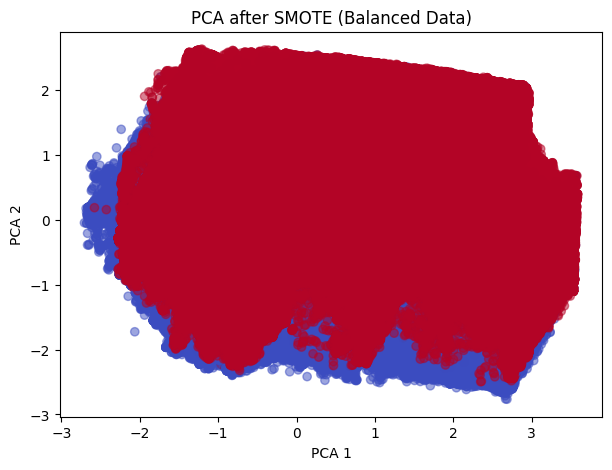

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train_res,
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA after SMOTE (Balanced Data)")

plt.show()

In [136]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pca, y_train_res)
y_pred_rf = rf.predict(X_test_pca)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.97      0.98    338460
           1       0.86      0.93      0.89     69282

    accuracy                           0.96    407742
   macro avg       0.92      0.95      0.94    407742
weighted avg       0.96      0.96      0.96    407742



In [137]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_pca, y_train_res)
y_pred_lr = lr.predict(X_test_pca)
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))



Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.90      0.94    338460
           1       0.66      0.89      0.76     69282

    accuracy                           0.90    407742
   macro avg       0.82      0.90      0.85    407742
weighted avg       0.92      0.90      0.91    407742



In [138]:
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']